In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [23]:
arquivo = files.upload()

Saving vinland.png to vinland (1).png


In [16]:
arquiv2 = files.upload()

Saving torffin.jpg to torffin (2).jpg


array([[ 17,  17,  17, ...,  12,  13,  13],
       [ 17,  17,  17, ...,  13,  14,  14],
       [ 17,  17,  17, ...,  14,  15,  15],
       ...,
       [ 97,  97,  97, ..., 133, 133, 134],
       [103, 103, 102, ..., 132, 133, 133],
       [105, 105, 105, ..., 131, 131, 131]], dtype=uint8)
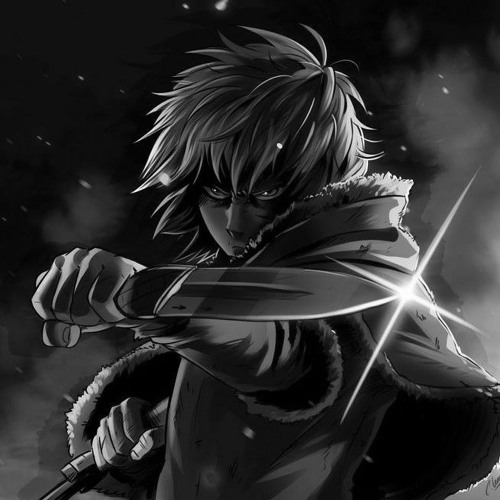

In [18]:
img_bgr2 = cv2.imread('torffin.jpg')
img_gray2 = cv2.cvtColor(img_bgr2, cv2.COLOR_BGR2GRAY)
img_gray2

array([[ 78,  73,  67, ..., 101,  95,  99],
       [ 67,  71,  71, ...,  99, 101, 101],
       [ 71,  71,  71, ..., 101, 101, 101],
       ...,
       [155, 155, 136, ..., 198, 198, 198],
       [142, 152, 151, ..., 198, 198, 198],
       [131, 160, 160, ..., 198, 201, 198]], dtype=uint8)
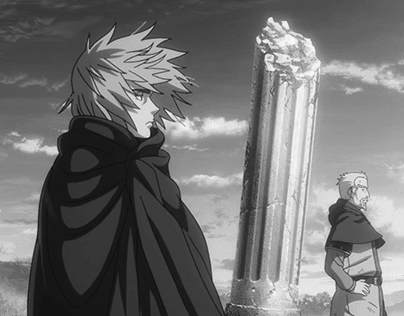

In [24]:
img_bgr = cv2.imread('vinland.png')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray

In [25]:
altura = img_gray.shape[0]
largura = img_gray.shape[1]
altura, largura

(316, 404)

Translação Exclusão

In [26]:
dx = 50
dy = 30

transladada = np.zeros((altura, largura), dtype=np.uint8)#uint8 - rgb tem 8bits 0-255



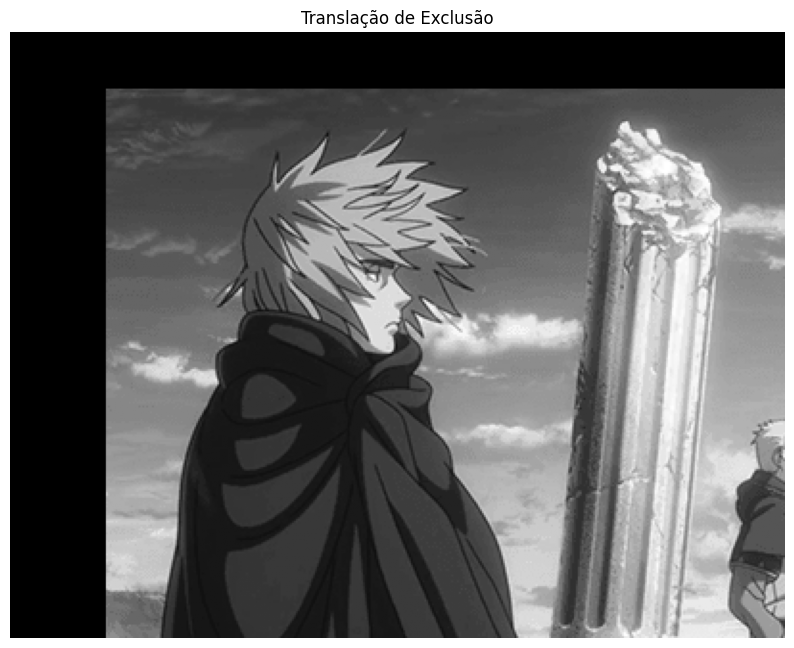

In [27]:
#percorrer img

for x in range(largura):
  for y in range(altura):
    novo_x = x + dx
    novo_y = y + dy

    if novo_x >= 0 and novo_x < largura:
      if novo_y >= 0 and novo_y < altura:
        transladada[novo_y, novo_x] = img_gray[y, x] #coordenada x  - coluna / img em pyhon é assim invertido

plt.figure(figsize=(10, 10))
plt.imshow(transladada, cmap='gray')
plt.title("Translação de Exclusão")
plt.axis('off')
plt.show()


Wrap Around

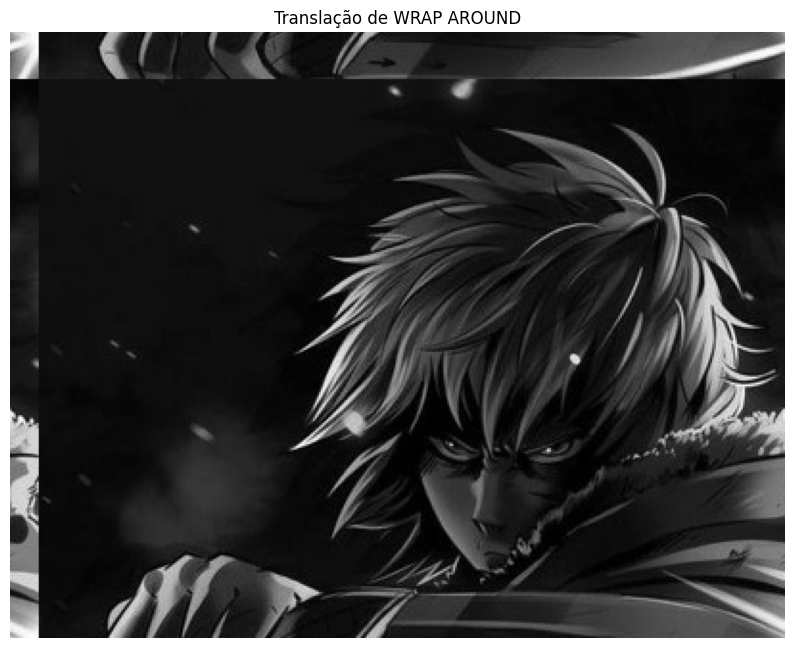

In [32]:
dx = 15
dy = 25

transladada = np.zeros((altura, largura), dtype=np.uint8)

# Adicionando os laços de repetição para percorrer todos os pixels
for x in range(largura):
  for y in range(altura):
    novo_x = (x + dx) % largura
    novo_y = (y + dy) % altura
    transladada[novo_y, novo_x] = img_gray2[y, x]

plt.figure(figsize=(10, 10))
plt.imshow(transladada, cmap='gray')
plt.title("Translação de WRAP AROUND")
plt.axis('off')
plt.show()

In [33]:
for i in range (28):
  print(i % 7)

0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6


Escalamento

(np.float64(-0.5), np.float64(201.5), np.float64(157.5), np.float64(-0.5))

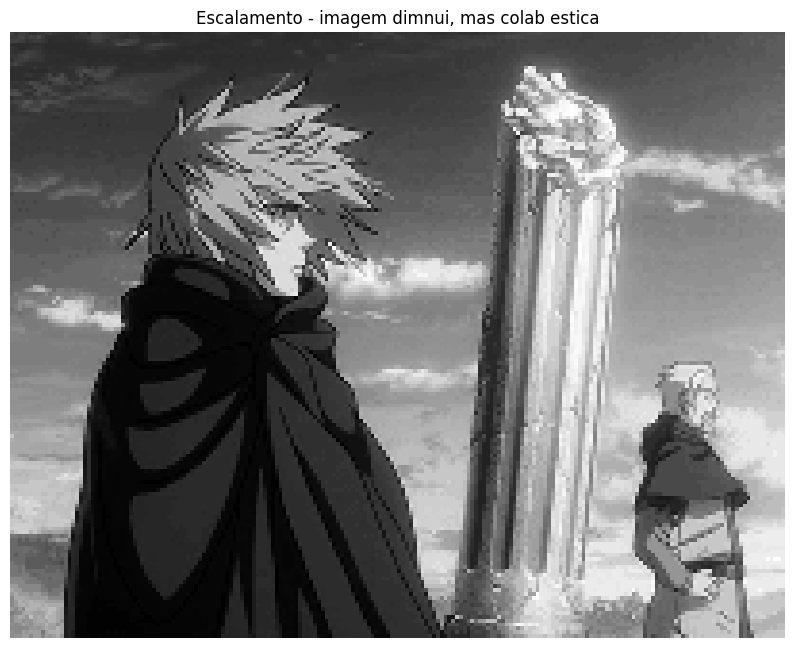

In [43]:
sx = 0.5
sy = 0.5

nova_largura = int(largura * sx)
nova_altura = int(altura * sy)
escalada = np.zeros((nova_altura, nova_largura), dtype=np.uint8)

for x in range(nova_largura):
  for y in range(nova_altura):

    novo_x = int(x / sx)
    novo_y = int(y / sy)

    escalada[y, x] = img_gray[novo_y, novo_x]

plt.figure(figsize=(10, 10))
plt.imsave('vinland04.jpg', escalada, cmap='gray')
plt.imshow(escalada, cmap='gray')
plt.title("Escalamento - imagem dimnui, mas colab estica")
plt.axis('off')

(np.float64(-0.5), np.float64(201.5), np.float64(157.5), np.float64(-0.5))

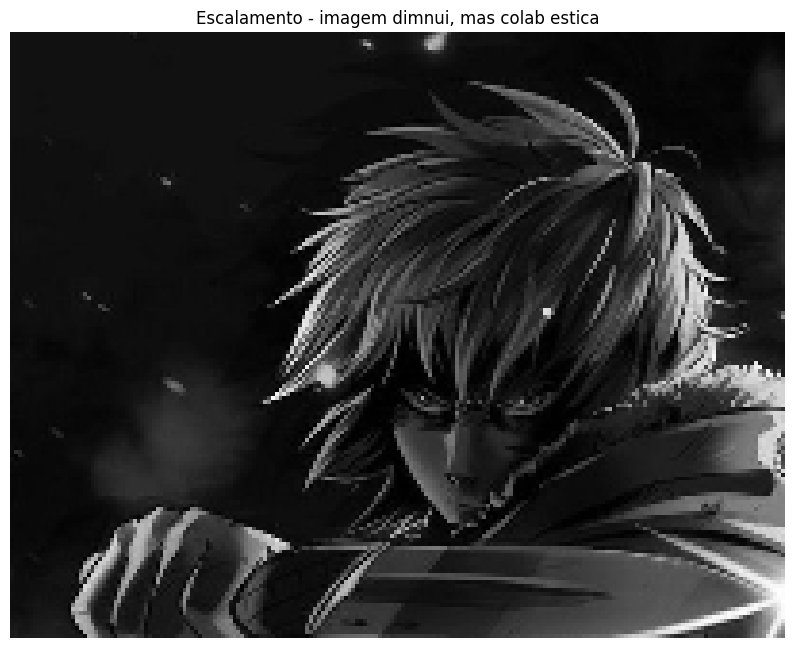

In [44]:
sx = 0.5
sy = 0.5

nova_largura = int(largura * sx)
nova_altura = int(altura * sy)
escalada = np.zeros((nova_altura, nova_largura), dtype=np.uint8)

for x in range(nova_largura):
  for y in range(nova_altura):

    novo_x = int(x / sx)
    novo_y = int(y / sy)

    escalada[y, x] = img_gray2[novo_y, novo_x]

plt.figure(figsize=(10, 10))
#plt.imsave('vinland04.jpg', escalada, cmap='gray')
plt.imshow(escalada, cmap='gray')
plt.title("Escalamento - imagem dimnui, mas colab estica")
plt.axis('off')

Espelhamento

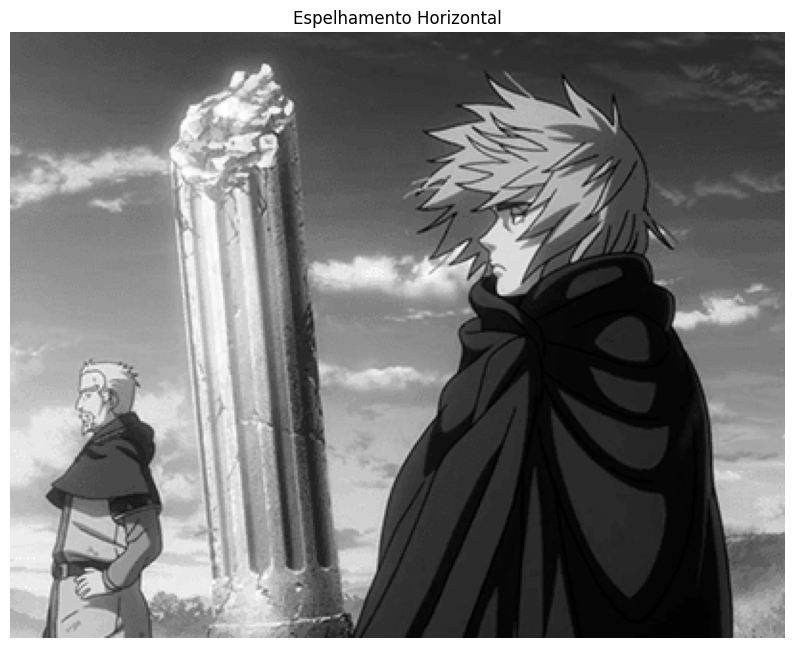

In [48]:
espelhada_h = np.zeros((altura, largura), dtype=np.uint8)
espelhada_v = np.zeros((altura, largura), dtype=np.uint8)

for x in range(largura):
  for y in range(altura):
    novo_x = largura - x - 1
    novo_y = y

    espelhada_h[novo_y, novo_x] = img_gray[y, x]

plt.figure(figsize=(10, 10))
plt.imshow(espelhada_h, cmap='gray')
plt.title("Espelhamento Horizontal")
plt.axis('off')
plt.show()

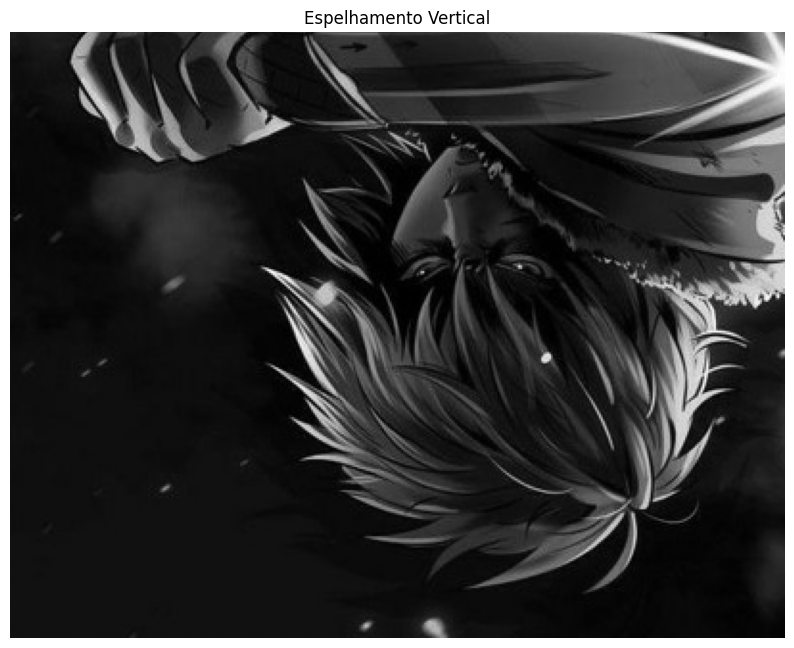

In [51]:
espelhada_v = np.zeros((altura, largura), dtype=np.uint8)

for x in range(largura):
  for y in range(altura):
    # Mantém o x e inverte o y
    novo_x = x
    novo_y = altura - y - 1

    espelhada_v[novo_y, novo_x] = img_gray2[y, x]

plt.figure(figsize=(10, 10))
plt.imshow(espelhada_v, cmap='gray')
plt.title("Espelhamento Vertical")
plt.axis('off')
plt.show()